# Set-up

In [17]:
# Importing libraries
import os
import glob
import json
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pyBigWig

def plot_tracks(tracks, interval, height=1.5, colors=None, sharey=False):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True, sharey=sharey)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

def plot_tracks_from_locus(locus, bws, colors, sharey=False):
    chrom, coord = locus.split(":")
    start, end = coord.split("-")
    start, end = int(start), int(end)
    interval = {"chrom": chrom, "start": int(start), "end": int(end)}
    tracks = {k: np.nan_to_num(np.array(bw.values(chrom, start, end))) for k, bw in bws.items()}
    plot_tracks(tracks, interval, height=1.5, colors=colors, sharey=sharey)

# Motifs

In [2]:
path_initial_motifs = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/tfs_initial.txt"
path_pngs = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/motifs/cluster"

In [3]:
initial_motifs = pd.read_csv(path_initial_motifs, sep="\t", header=None)
initial_motifs.columns = ["cluster_name", "top_tomtom_annotation", "evalue"]
initial_motifs["png_path"] = initial_motifs["cluster_name"].apply(lambda x: f"{path_pngs}/{x}.png")
initial_motifs

,cluster_name,top_tomtom_annotation,evalue,png_path
0,Average_34,ZN143_MOUSE.H11MO.0.A,7.873220e-22,/cellar/users/aklie/data/datasets/sc-islet-dif...
1,Average_15,CTCF_MA0139.1,2.569710e-17,/cellar/users/aklie/data/datasets/sc-islet-dif...
2,Average_23,NFYB_HUMAN.H11MO.0.A,8.913720e-14,/cellar/users/aklie/data/datasets/sc-islet-dif...
3,Average_30,HNF4G_MA0484.1,2.322600e-11,/cellar/users/aklie/data/datasets/sc-islet-dif...
4,Average_18,NRF1_HUMAN.H11MO.0.A,1.435680e-10,/cellar/users/aklie/data/datasets/sc-islet-dif...
5,Average_39,MAFB_HUMAN.H11MO.0.B,9.966660e-10,/cellar/users/aklie/data/datasets/sc-islet-dif...
6,Average_38,NDF2_MOUSE.H11MO.0.A,6.502500e-09,/cellar/users/aklie/data/datasets/sc-islet-dif...
7,Average_27,SP2_HUMAN.H11MO.0.A,1.042770e-08,/cellar/users/aklie/data/datasets/sc-islet-dif...
8,D15_ENP.counts.pattern_32.pfm,ETV6_ETS_1,4.564920e-08,/cellar/users/aklie/data/datasets/sc-islet-dif...
9,Average_14,HNF1B_MA0153.2,5.813290e-08,/cellar/users/aklie/data/datasets/sc-islet-dif...


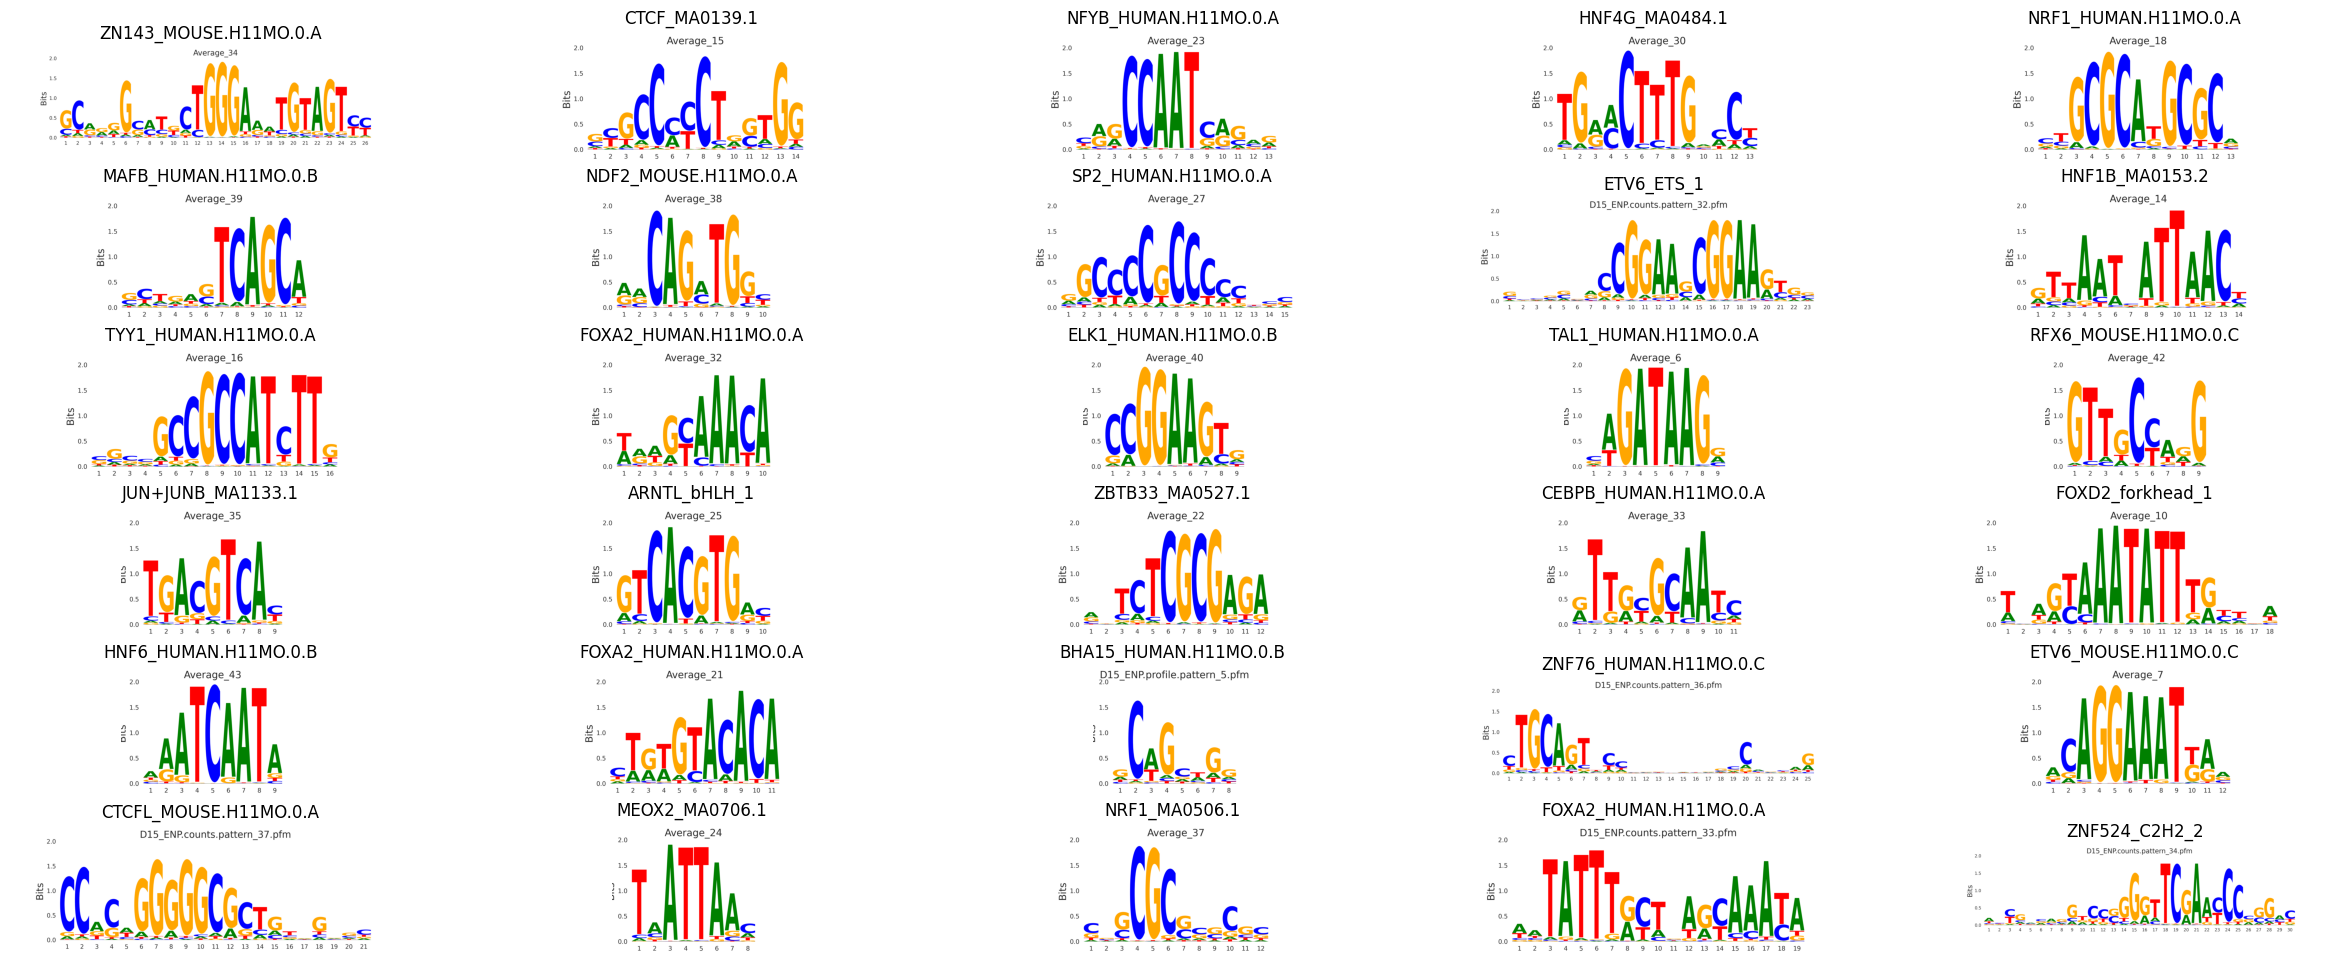

In [6]:
n_cols = 5
n_rows = (len(initial_motifs) + n_cols - 1) // n_cols  # Calculate number of rows needed
#n_rows = (20 + n_cols - 1) // n_cols  # Calculate number of rows needed

# create a single figure with subplots for each cluster, annotate with top_tomtom_annotation
# make sure each plot is same size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 2 * n_rows))
for i, (index, row) in enumerate(initial_motifs.iterrows()):
    ax = axes[i // n_cols, i % n_cols]
    img = plt.imread(row["png_path"])
    ax.imshow(img)
    ax.set_title(f"{row['top_tomtom_annotation']}")
    ax.axis('off')
# Remove empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])
#plt.savefig(f"{path_out}/summary/initial_motifs.png")

# Model browser sessions

In [18]:
celltypes = ["SC.beta"]
bucket = "gs://2025_01_06"

In [26]:
path_peaks = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_06_15/D15_merged_ENP_peaks.sorted.bed.gz"
path_observed_bw = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw"
path_predictions_bw = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/average/predictions/D15_ENP_chrombpnet_nobias.bw"
path_counts_contributions_bw = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/average/contributions/D15_ENP_counts.bw"
path_profile_contributions_bw = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/average/contributions/D15_ENP_profile.bw"
path_counts_motif_hits = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_06_15/counts_hits.sorted.bed.gz"
path_profile_motif_hits = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_06_15/profile_hits.sorted.bed.gz"

In [27]:
path_out = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/scratch/2025_06_15"

## Bigwigs

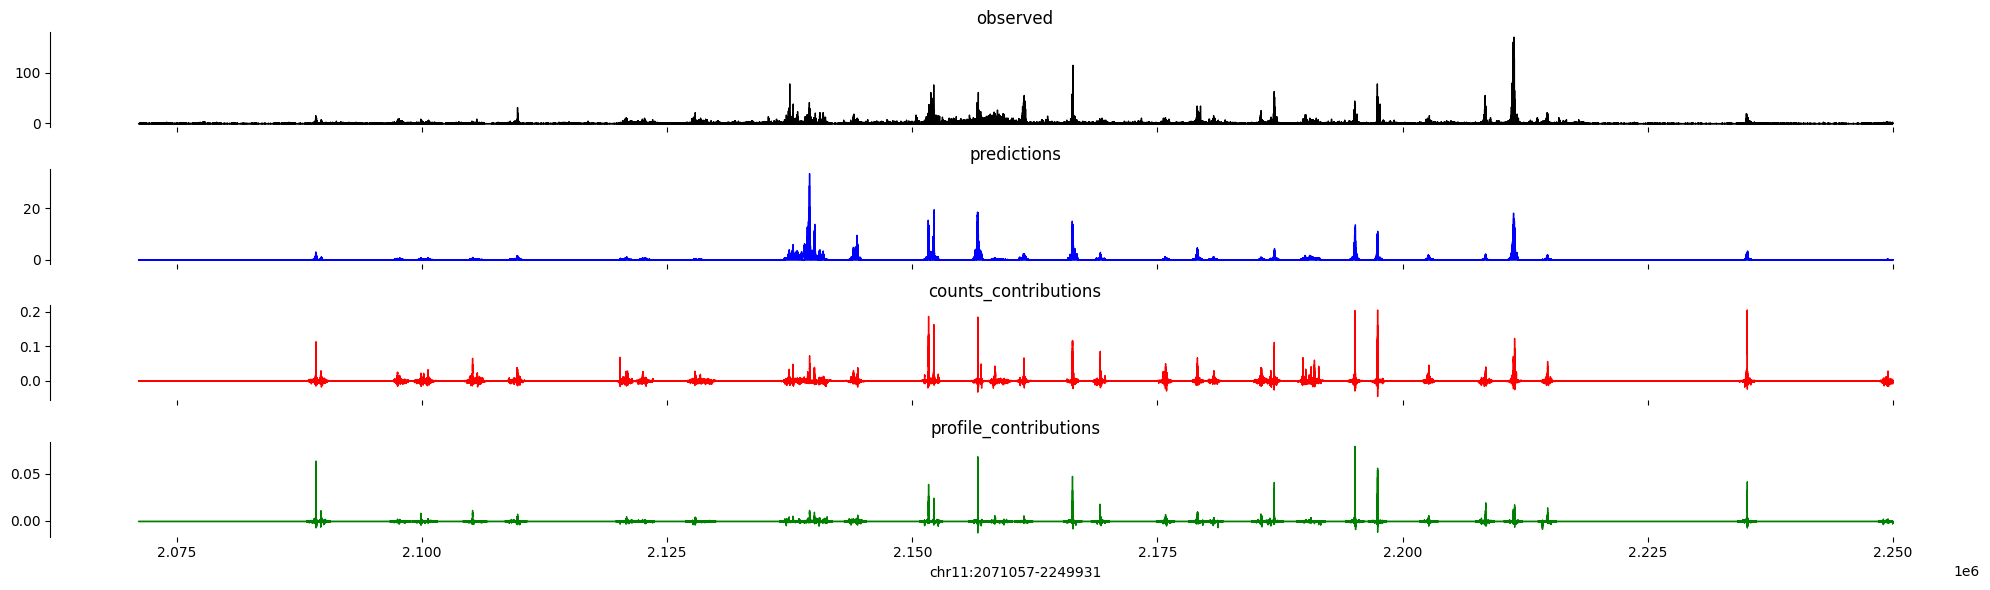

In [28]:
bw_dict = {
    "observed": pyBigWig.open(path_observed_bw),
    "predictions": pyBigWig.open(path_predictions_bw),
    "counts_contributions": pyBigWig.open(path_counts_contributions_bw),
    "profile_contributions": pyBigWig.open(path_profile_contributions_bw),
}
colors = {
    "observed": "black",
    "predictions": "blue",
    "counts_contributions": "red",
    "profile_contributions": "green",
}
locus = "chr11:2071057-2249931"
plot_tracks_from_locus(locus, bw_dict, colors=colors)

In [31]:
# Secure copy all files to bucket

# peaks (both gz and tbi)
cmd = f"gsutil cp {path_peaks} gs://2025_01_06/D15_merged_ENP_peaks.sorted.bed.gz"
#os.system(cmd)
cmd = f"gsutil cp {path_peaks}.tbi gs://2025_01_06/D15_merged_ENP_peaks.sorted.bed.gz.tbi"
#os.system(cmd)

# observed bw
cmd = f"gsutil cp {path_observed_bw} gs://2025_01_06/D15_ENP_observed.bw"
os.system(cmd)

# predictions bw
cmd = f"gsutil cp {path_predictions_bw} gs://2025_01_06/D15_ENP_predictions.bw"
os.system(cmd)

# counts contributions bw
cmd = f"gsutil cp {path_counts_contributions_bw} gs://2025_01_06/D15_ENP_counts_contributions.bw"
os.system(cmd)

# profile contributions bw
cmd = f"gsutil cp {path_profile_contributions_bw} gs://2025_01_06/D15_ENP_profile_contributions.bw"
os.system(cmd)

# counts motif hits (both gz and tbi)
cmd = f"gsutil cp {path_counts_motif_hits} gs://2025_01_06/D15_ENP_counts_hits.sorted.bed.gz" 
os.system(cmd)
cmd = f"gsutil cp {path_counts_motif_hits}.tbi gs://2025_01_06/D15_ENP_counts_hits.sorted.bed.gz.tbi"
os.system(cmd)

# profile motif hits (both gz and tbi)
cmd = f"gsutil cp {path_profile_motif_hits} gs://2025_01_06/D15_ENP_profile_hits.sorted.bed.gz"
os.system(cmd)
cmd = f"gsutil cp {path_profile_motif_hits}.tbi gs://2025_01_06/D15_ENP_profile_hits.sorted.bed.gz.tbi"
os.system(cmd)

Copying file:///cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/models/D15_ENP/fold_0/chrombpnet/0.5/auxiliary/data_unstranded.bw [Content-Type=application/octet-stream]...
==> NOTE: You are uploading one or more large file(s), which would run          
significantly faster if you enable parallel composite uploads. This
feature can be enabled by editing the
"parallel_composite_upload_threshold" value in your .boto
configuration file. However, note that if you do this large files will
be uploaded as `composite objects
<https://cloud.google.com/storage/docs/composite-objects>`_,which
means that any user who downloads such objects will need to have a
compiled crcmod installed (see "gsutil help crcmod"). This is because
without a compiled crcmod, computing checksums on composite objects is
so slow that gsutil disables downloads of composite objects.

| [1 files][436.4 MiB/436.4 MiB]                                                
Operation completed over 1 objects/43

0

# DONE!

---